In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

BASE = Path().resolve().parent
RAW  = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"
RPT  = BASE / "reports"
RPT.mkdir(exist_ok=True)

# ── Load all data ──────────────────────────────────────────────
nav  = pd.read_csv(PROC / "clean_nav_history.csv")
txn  = pd.read_csv(PROC / "clean_investor_transactions.csv")
port = pd.read_csv(PROC / "clean_portfolio_holdings.csv")
fm   = pd.read_csv(PROC / "clean_fund_master.csv")
perf = pd.read_csv(PROC / "clean_scheme_performance.csv")

nav["date"]              = pd.to_datetime(nav["date"])
txn["transaction_date"]  = pd.to_datetime(txn["transaction_date"])
port["portfolio_date"]   = pd.to_datetime(port["portfolio_date"])

# Compute daily returns (needed for VaR and rolling Sharpe)
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
returns = nav.dropna(subset=["daily_return"]).copy()

print("✓ All data loaded")
print(f"  NAV returns : {returns.shape}")
print(f"  Transactions: {txn.shape}")
print(f"  Holdings    : {port.shape}")
print(f"  Funds       : {fm.shape}")

✓ All data loaded
  NAV returns : (45960, 4)
  Transactions: (32778, 13)
  Holdings    : (322, 8)
  Funds       : (40, 15)


In [31]:
# ── Historical VaR and CVaR for all 40 funds ──────────────────
# VaR  = 5th percentile of daily return distribution
# CVaR = mean of all returns BELOW the VaR threshold

var_list = []
for code, group in returns.groupby("amfi_code"):
    r = group["daily_return"].dropna()

    var_95  = np.percentile(r, 5)           # 5th percentile
    cvar_95 = r[r <= var_95].mean()         # mean of worst days

    # Annualised VaR (scale by sqrt(252))
    var_ann  = var_95  * np.sqrt(252) * 100
    cvar_ann = cvar_95 * np.sqrt(252) * 100

    var_list.append({
        "amfi_code"     : code,
        "var_95_daily"  : round(var_95  * 100, 4),   # daily %
        "cvar_95_daily" : round(cvar_95 * 100, 4),   # daily %
        "var_95_ann"    : round(var_ann,  4),          # annualised %
        "cvar_95_ann"   : round(cvar_ann, 4),          # annualised %
        "worst_day_pct" : round(r.min() * 100, 4),
        "best_day_pct"  : round(r.max() * 100, 4),
        "n_days"        : len(r)
    })

var_df = pd.DataFrame(var_list)
var_df = var_df.merge(
    fm[["amfi_code","scheme_name","fund_house","category","plan","risk_category"]],
    on="amfi_code"
)
var_df = var_df.sort_values("var_95_daily").reset_index(drop=True)

print("=== VAR & CVAR REPORT — ALL 40 FUNDS ===")
print("Sorted by worst VaR (most risky first)")
print()
print(var_df[["scheme_name","category","var_95_daily",
              "cvar_95_daily","worst_day_pct","best_day_pct"]].to_string())

var_df.to_csv(PROC / "var_cvar_report.csv", index=False)
print(f"\n✓ Saved var_cvar_report.csv — {len(var_df)} funds")

=== VAR & CVAR REPORT — ALL 40 FUNDS ===
Sorted by worst VaR (most risky first)

                                              scheme_name category  var_95_daily  cvar_95_daily  worst_day_pct  best_day_pct
0               SBI Small Cap Fund - Direct Plan - Growth   Equity       -2.6859        -3.2384        -4.5429        5.3320
1                  Axis Small Cap Fund - Regular - Growth   Equity       -2.6188        -3.1667        -4.8367        4.3110
2                  ABSL Small Cap Fund - Regular - Growth   Equity       -2.6021        -3.2459        -5.1847        5.4851
3          Nippon India Small Cap Fund - Regular - Growth   Equity       -2.5438        -3.2304        -5.8102        5.9304
4              SBI Small Cap Fund - Regular Plan - Growth   Equity       -2.4507        -3.0595        -4.5180        6.4713
5                   DSP Small Cap Fund - Regular - Growth   Equity       -2.3483        -3.1036        -4.8870        4.8490
6                     UTI Mid Cap Fund - Reg

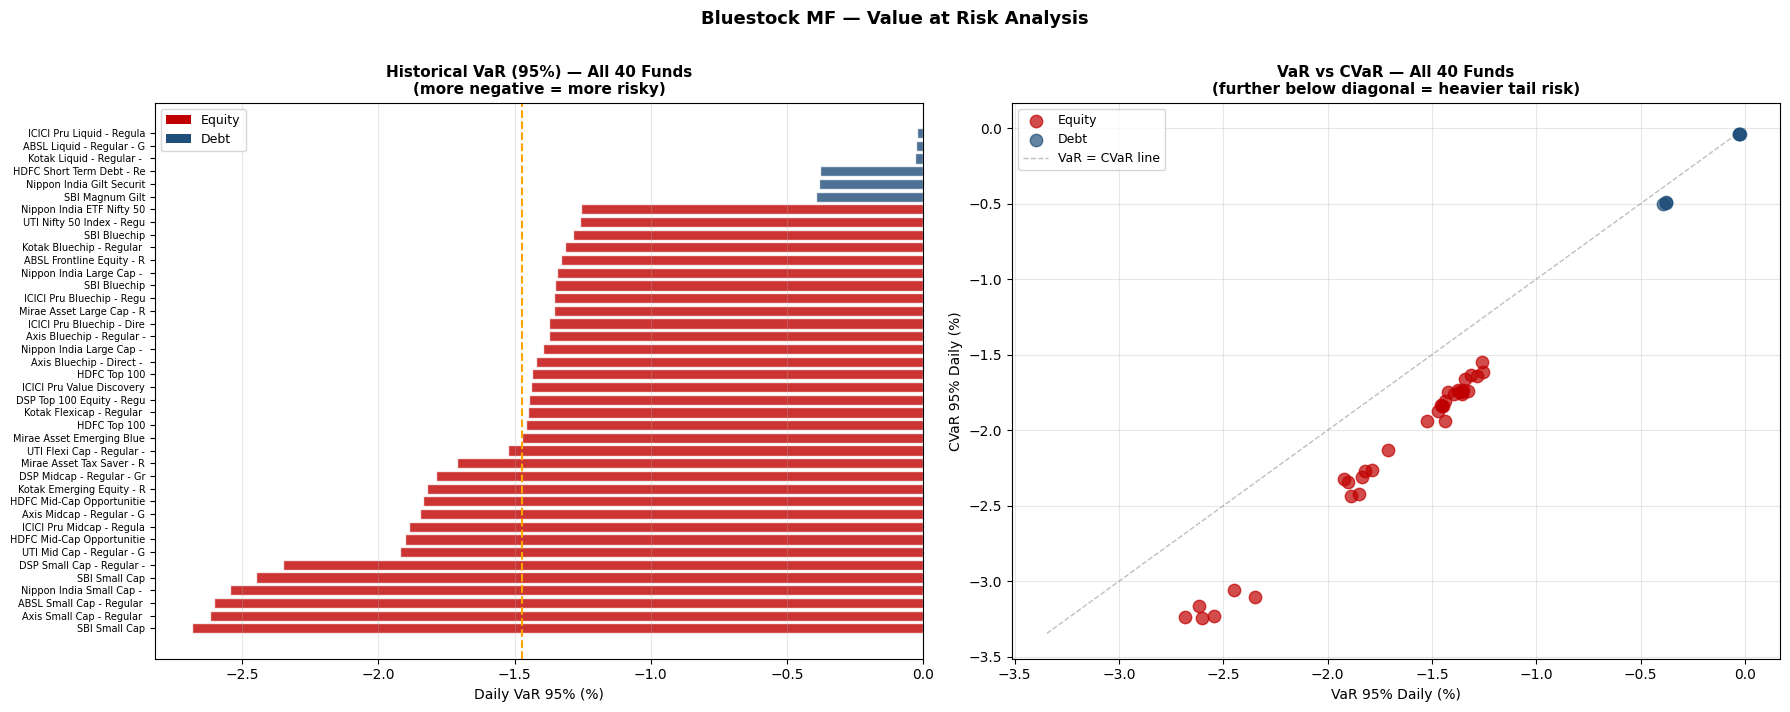

✓ Saved var_cvar_chart.png


In [32]:
# ── VaR Chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — VaR by fund (horizontal bar)
ax1 = axes[0]
colors = ["#C00000" if c == "Equity" else "#1F4E79"
          for c in var_df["category"]]
short_names = [n.replace(" - Regular Plan - Growth","")
                .replace(" - Direct Plan - Growth","")
                .replace(" Fund","")[:25]
               for n in var_df["scheme_name"]]

bars = ax1.barh(range(len(var_df)), var_df["var_95_daily"],
                color=colors, alpha=0.8, edgecolor="white")
ax1.set_yticks(range(len(var_df)))
ax1.set_yticklabels(short_names, fontsize=7)
ax1.set_xlabel("Daily VaR 95% (%)", fontsize=10)
ax1.set_title("Historical VaR (95%) — All 40 Funds\n(more negative = more risky)",
              fontsize=11, fontweight="bold")
ax1.axvline(x=var_df["var_95_daily"].mean(), color="orange",
            linestyle="--", linewidth=1.5, label=f"Avg: {var_df['var_95_daily'].mean():.2f}%")
ax1.legend(fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#C00000", label="Equity"),
                   Patch(facecolor="#1F4E79", label="Debt")]
ax1.legend(handles=legend_elements, fontsize=9)
ax1.grid(True, alpha=0.3, axis="x")

# Chart 2 — VaR vs CVaR scatter
ax2 = axes[1]
eq = var_df[var_df["category"] == "Equity"]
dt = var_df[var_df["category"] == "Debt"]

ax2.scatter(eq["var_95_daily"], eq["cvar_95_daily"],
            color="#C00000", s=80, alpha=0.7, label="Equity", zorder=5)
ax2.scatter(dt["var_95_daily"], dt["cvar_95_daily"],
            color="#1F4E79", s=80, alpha=0.7, label="Debt", zorder=5)

# Diagonal reference line
lim = min(var_df["var_95_daily"].min(), var_df["cvar_95_daily"].min()) - 0.1
ax2.plot([lim, 0], [lim, 0], color="gray", linestyle="--",
         linewidth=1, alpha=0.5, label="VaR = CVaR line")

ax2.set_xlabel("VaR 95% Daily (%)", fontsize=10)
ax2.set_ylabel("CVaR 95% Daily (%)", fontsize=10)
ax2.set_title("VaR vs CVaR — All 40 Funds\n(further below diagonal = heavier tail risk)",
              fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Bluestock MF — Value at Risk Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RPT / "var_cvar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved var_cvar_chart.png")

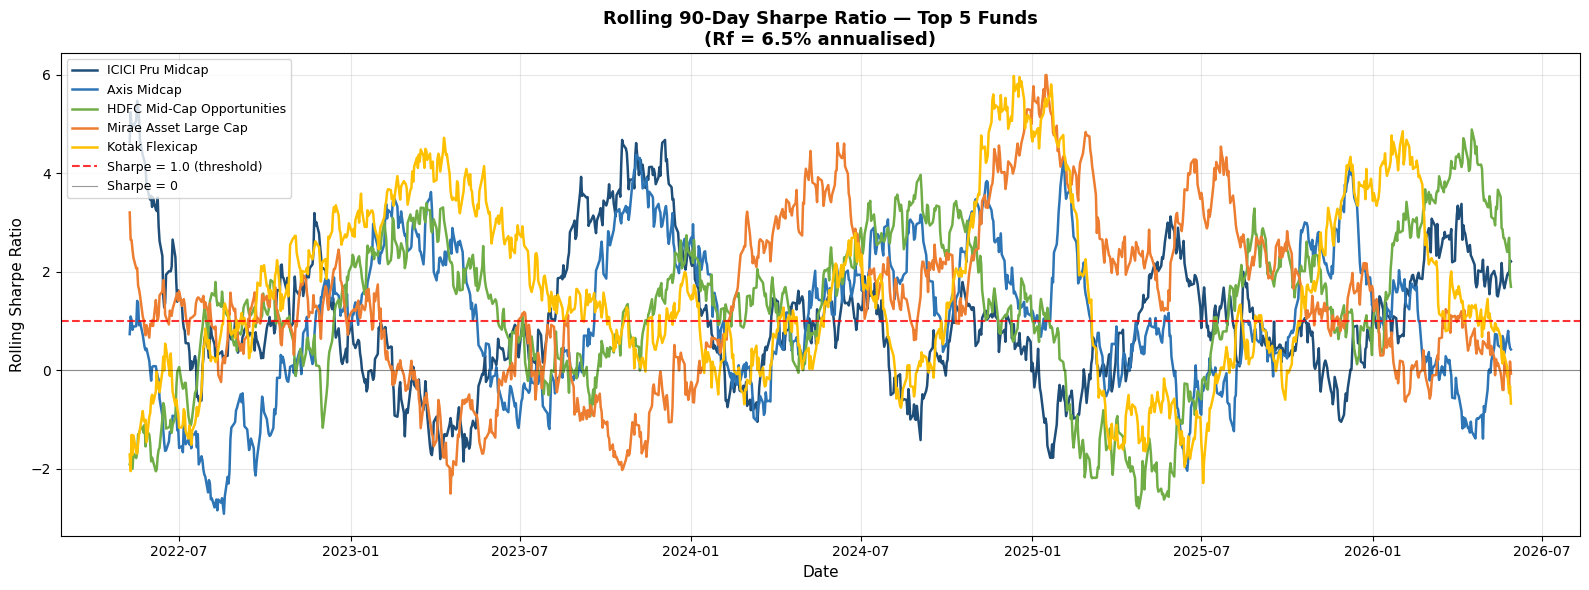

✓ Saved rolling_sharpe_chart.png


In [33]:
# ── Rolling 90-Day Sharpe for top 5 funds ─────────────────────
# Formula: returns.rolling(90).mean() / returns.rolling(90).std() * sqrt(252)
# Use top 5 from scorecard — or 5 well-known funds

Rf_daily = 0.065 / 252

# Load scorecard to get top 5
scorecard = pd.read_csv(PROC / "fund_scorecard.csv")
top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"].to_dict()

def short_name(n):
    return (n.replace(" - Regular Plan - Growth","")
             .replace(" - Direct Plan - Growth","")
             .replace(" - Regular - Growth","")
             .replace(" Fund","")[:28])

fig, ax = plt.subplots(figsize=(16, 6))
colors = ["#1F4E79","#2E75B6","#70AD47","#ED7D31","#FFC000"]

for i, code in enumerate(top5_codes):
    r = (returns[returns["amfi_code"] == code]
         .sort_values("date")
         .set_index("date")["daily_return"])

    # PDF formula: rolling(90).mean() / rolling(90).std() * sqrt(252)
    rolling_mean   = r.rolling(90).mean()
    rolling_std    = r.rolling(90).std()
    rolling_sharpe = (rolling_mean - Rf_daily) / rolling_std * np.sqrt(252)

    ax.plot(rolling_sharpe.index, rolling_sharpe,
            color=colors[i], linewidth=1.8,
            label=short_name(top5_names[code]))

ax.axhline(y=1.0, color="red", linestyle="--",
           linewidth=1.5, alpha=0.8, label="Sharpe = 1.0 (threshold)")
ax.axhline(y=0.0, color="black", linestyle="-",
           linewidth=0.8, alpha=0.4, label="Sharpe = 0")

ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds\n(Rf = 6.5% annualised)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Rolling Sharpe Ratio", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RPT / "rolling_sharpe_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved rolling_sharpe_chart.png")

In [34]:
# ── Investor Cohort Analysis ───────────────────────────────────
# Group by FIRST transaction year → 2024 or 2025
# Compute avg SIP amount, total invested, top fund per cohort

# Step 1 — assign cohort year per investor
first_txn = (txn.groupby("investor_id")["transaction_date"]
                .min()
                .reset_index())
first_txn["cohort_year"] = first_txn["transaction_date"].dt.year
txn_cohort = txn.merge(first_txn[["investor_id","cohort_year"]], on="investor_id")

# Step 2 — SIP transactions only for cohort SIP analysis
sip_cohort = txn_cohort[txn_cohort["transaction_type"] == "SIP"]

# Step 3 — Compute cohort metrics
cohort_summary = (txn_cohort.groupby("cohort_year")
                             .agg(
                                 total_investors   = ("investor_id", "nunique"),
                                 total_invested    = ("amount_inr", "sum"),
                                 avg_txn_amount    = ("amount_inr", "mean"),
                                 total_txn_count   = ("investor_id", "count"),
                             )
                             .reset_index())
cohort_summary["avg_total_per_investor"] = (
    cohort_summary["total_invested"] / cohort_summary["total_investors"]
).round(2)
cohort_summary["total_invested_cr"] = (
    cohort_summary["total_invested"] / 1e7
).round(2)

print("=== COHORT SUMMARY ===")
print(cohort_summary.to_string())

# Step 4 — SIP amount by cohort
sip_cohort_stats = (sip_cohort.groupby("cohort_year")
                               .agg(
                                   avg_sip_amount  = ("amount_inr", "mean"),
                                   median_sip      = ("amount_inr", "median"),
                                   total_sip_count = ("investor_id", "count"),
                                   sip_investors   = ("investor_id", "nunique")
                               )
                               .reset_index())
print("\n=== SIP METRICS BY COHORT ===")
print(sip_cohort_stats.to_string())

# Step 5 — Top fund preference per cohort
top_fund_cohort = (txn_cohort.groupby(["cohort_year","amfi_code"])
                              .agg(total_amount=("amount_inr","sum"),
                                   txn_count=("investor_id","count"))
                              .reset_index()
                              .merge(fm[["amfi_code","scheme_name"]], on="amfi_code"))
top_fund_per_cohort = (top_fund_cohort.sort_values("total_amount", ascending=False)
                                       .groupby("cohort_year")
                                       .head(3)
                                       .reset_index(drop=True))
print("\n=== TOP 3 FUND PREFERENCES PER COHORT ===")
print(top_fund_per_cohort[["cohort_year","scheme_name",
                            "total_amount","txn_count"]].to_string())

# Step 6 — Save
cohort_df = txn_cohort.groupby(["cohort_year","investor_id"]).agg(
    total_invested  = ("amount_inr","sum"),
    avg_sip_amount  = ("amount_inr","mean"),
    txn_count       = ("investor_id","count"),
).reset_index()
cohort_df.to_csv(PROC / "cohort_analysis.csv", index=False)
print(f"\n✓ Saved cohort_analysis.csv — {len(cohort_df)} rows")

=== COHORT SUMMARY ===
   cohort_year  total_investors  total_invested  avg_txn_amount  total_txn_count  avg_total_per_investor  total_invested_cr
0         2024             4803      3491125187   107422.541832            32499               726863.46             349.11
1         2025              197        30455243   109158.577061              279               154595.14               3.05

=== SIP METRICS BY COHORT ===
Empty DataFrame
Columns: [cohort_year, avg_sip_amount, median_sip, total_sip_count, sip_investors]
Index: []

=== TOP 3 FUND PREFERENCES PER COHORT ===
   cohort_year                                            scheme_name  total_amount  txn_count
0         2024             UTI Nifty 50 Index Fund - Regular - Growth     100126141        827
1         2024  Mirae Asset Emerging Bluechip Fund - Regular - Growth      98075514        874
2         2024                    Axis Midcap Fund - Regular - Growth      96063579        840
3         2025              SBI Small Cap 

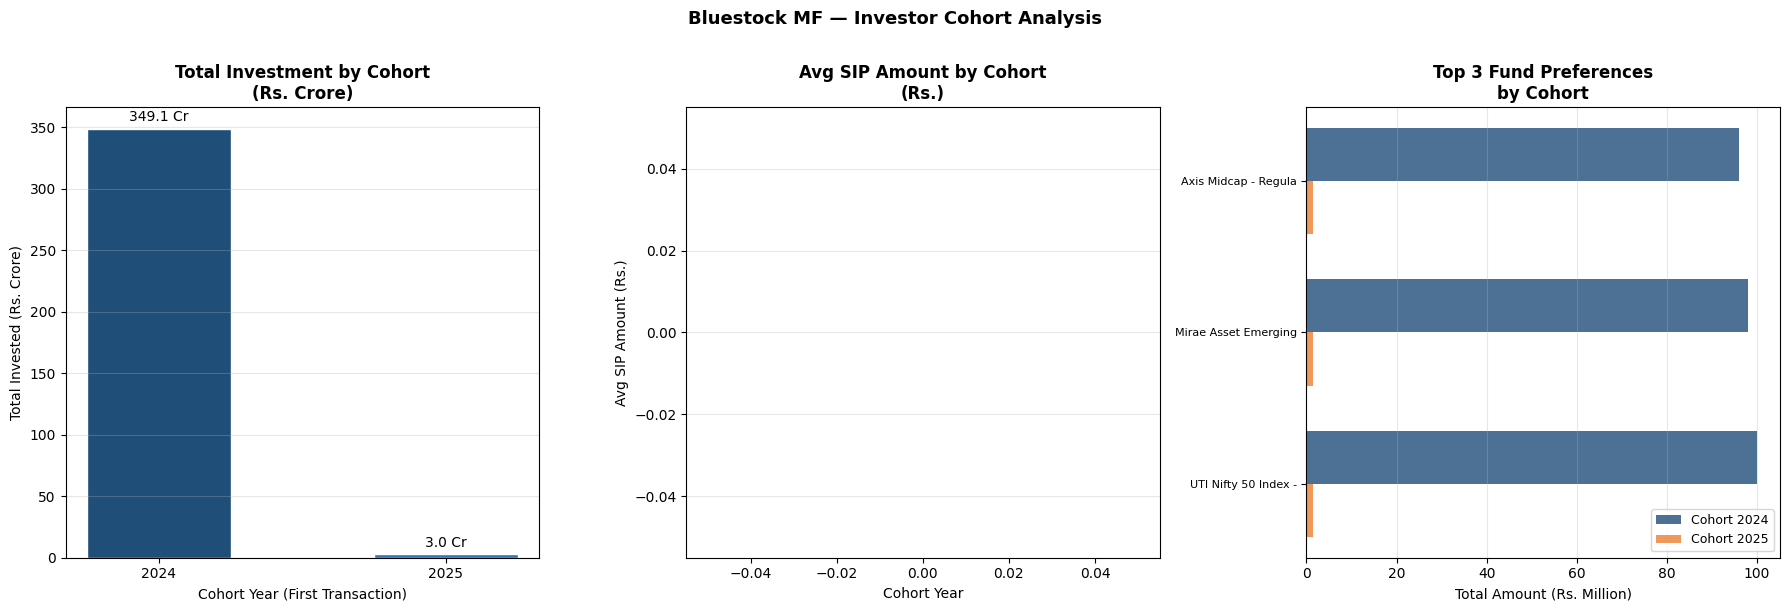

✓ Saved cohort_analysis_chart.png


In [35]:
# ── Cohort Visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 — Total invested by cohort
ax1 = axes[0]
bars = ax1.bar(cohort_summary["cohort_year"].astype(str),
               cohort_summary["total_invested_cr"],
               color=["#1F4E79","#2E75B6"], edgecolor="white", width=0.5)
ax1.bar_label(bars, fmt="%.1f Cr", fontsize=10, padding=3)
ax1.set_title("Total Investment by Cohort\n(Rs. Crore)", fontweight="bold")
ax1.set_xlabel("Cohort Year (First Transaction)")
ax1.set_ylabel("Total Invested (Rs. Crore)")
ax1.grid(True, alpha=0.3, axis="y")

# Chart 2 — Avg SIP amount by cohort
ax2 = axes[1]
bars2 = ax2.bar(sip_cohort_stats["cohort_year"].astype(str),
                sip_cohort_stats["avg_sip_amount"],
                color=["#70AD47","#ED7D31"], edgecolor="white", width=0.5)
ax2.bar_label(bars2, fmt="Rs.%.0f", fontsize=10, padding=3)
ax2.set_title("Avg SIP Amount by Cohort\n(Rs.)", fontweight="bold")
ax2.set_xlabel("Cohort Year")
ax2.set_ylabel("Avg SIP Amount (Rs.)")
ax2.grid(True, alpha=0.3, axis="y")

# Chart 3 — Top funds by cohort
ax3 = axes[2]
cohort_2024 = top_fund_per_cohort[top_fund_per_cohort["cohort_year"]==2024].head(3)
cohort_2025 = top_fund_per_cohort[top_fund_per_cohort["cohort_year"]==2025].head(3)

y_2024 = [n.replace(" - Regular Plan - Growth","")
           .replace(" Fund","")[:20]
           for n in cohort_2024["scheme_name"]]
y_2025 = [n.replace(" - Regular Plan - Growth","")
           .replace(" Fund","")[:20]
           for n in cohort_2025["scheme_name"]]

x = np.arange(3)
w = 0.35
ax3.barh(x + w/2, cohort_2024["total_amount"]/1e6, w,
         label="Cohort 2024", color="#1F4E79", alpha=0.8)
ax3.barh(x - w/2, cohort_2025["total_amount"]/1e6, w,
         label="Cohort 2025", color="#ED7D31", alpha=0.8)
ax3.set_yticks(x)
ax3.set_yticklabels(y_2024, fontsize=8)
ax3.set_xlabel("Total Amount (Rs. Million)")
ax3.set_title("Top 3 Fund Preferences\nby Cohort", fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis="x")

plt.suptitle("Bluestock MF — Investor Cohort Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RPT / "cohort_analysis_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved cohort_analysis_chart.png")

In [36]:
# ── SIP Continuity Analysis ────────────────────────────────────

# Step 0 — find correct SIP label
print("Transaction types:", txn["transaction_type"].unique())
sip_label = [t for t in txn["transaction_type"].unique() 
             if t.upper() == "SIP"][0]
print(f"Using SIP label: '{sip_label}'")

sip = txn[txn["transaction_type"] == sip_label].sort_values(
    ["investor_id", "transaction_date"]
).copy()

sip_counts       = sip.groupby("investor_id").size()
eligible_investors = sip_counts[sip_counts >= 6].index
sip_eligible     = sip[sip["investor_id"].isin(eligible_investors)].copy()

print(f"Total SIP investors       : {sip['investor_id'].nunique():,}")
print(f"Investors with 6+ SIPs    : {len(eligible_investors):,}")

# Compute gap between consecutive SIP transactions
sip_eligible["gap_days"] = (
    sip_eligible.groupby("investor_id")["transaction_date"]
                .diff().dt.days
)

# Summary per investor
continuity = (sip_eligible.groupby("investor_id")
                           .agg(
                               sip_count      = ("transaction_date", "count"),
                               avg_gap_days   = ("gap_days", "mean"),
                               max_gap_days   = ("gap_days", "max"),
                               min_gap_days   = ("gap_days", "min"),
                               total_invested = ("amount_inr", "sum")
                           )
                           .reset_index())

continuity = continuity.dropna(subset=["avg_gap_days"])
continuity["avg_gap_days"] = continuity["avg_gap_days"].round(1)
continuity["max_gap_days"] = continuity["max_gap_days"].round(1)
continuity["at_risk"]      = continuity["avg_gap_days"] > 35

at_risk_count = int(continuity["at_risk"].sum())
regular_count = int((~continuity["at_risk"]).sum())
at_risk_pct   = float(at_risk_count / len(continuity) * 100)

print(f"Regular: {regular_count}, At-risk: {at_risk_count}, Pct: {at_risk_pct:.1f}%")

print(f"\nSIP Continuity Results:")
print(f"  Regular (gap ≤ 35 days): {regular_count:,} ({100-at_risk_pct:.1f}%)")
print(f"  At-risk (gap > 35 days): {at_risk_count:,} ({at_risk_pct:.1f}%)")
print(f"\nGap statistics (days):")
print(continuity["avg_gap_days"].describe().round(2))

continuity.to_csv(PROC / "sip_continuity.csv", index=False)
print(f"\n✓ Saved sip_continuity.csv — {len(continuity)} investors")

Transaction types: <StringArray>
['Sip', 'Redemption', 'Lumpsum']
Length: 3, dtype: str
Using SIP label: 'Sip'
Total SIP investors       : 4,762
Investors with 6+ SIPs    : 1,362
Regular: 30, At-risk: 1332, Pct: 97.8%

SIP Continuity Results:
  Regular (gap ≤ 35 days): 30 (2.2%)
  At-risk (gap > 35 days): 1,332 (97.8%)

Gap statistics (days):
count    1362.00
mean       64.89
std        15.59
min        19.80
25%        53.62
50%        64.70
75%        75.57
max       102.60
Name: avg_gap_days, dtype: float64

✓ Saved sip_continuity.csv — 1362 investors


Type of regular_count: <class 'int'>, value: 30
Type of at_risk_count: <class 'int'>, value: 1332
Any NaN in continuity avg_gap_days: 0
r_count: 30, a_count: 1332


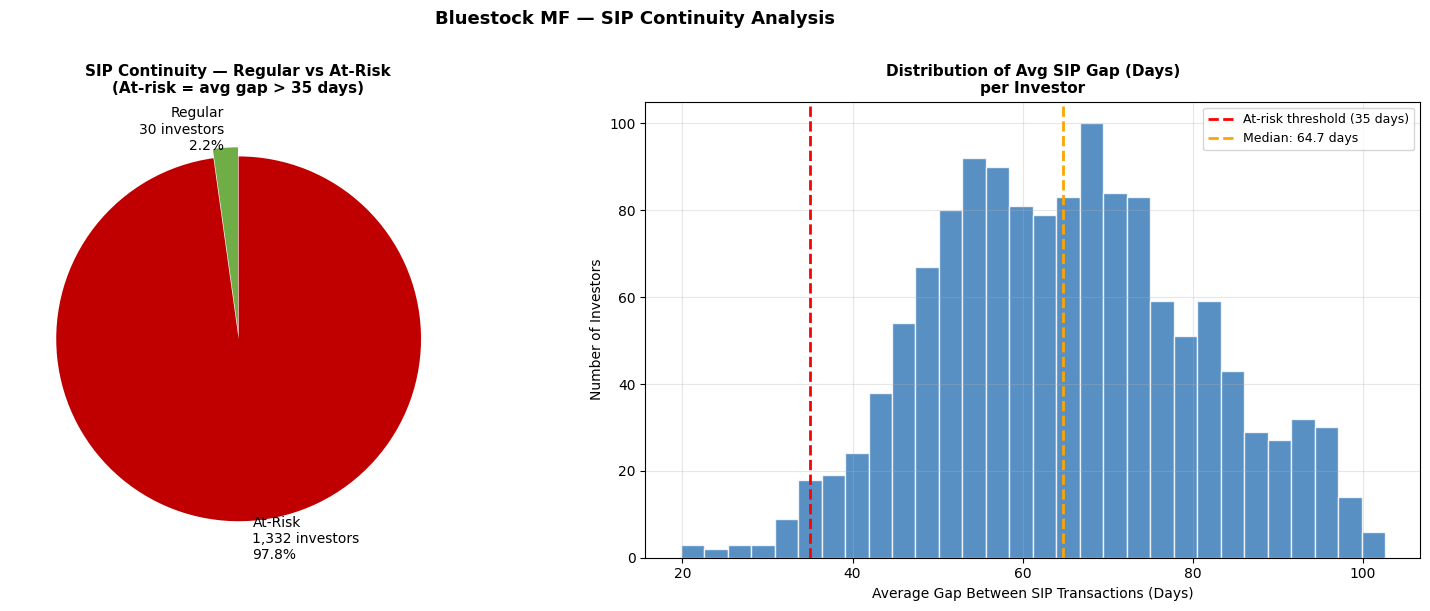

✓ Saved sip_continuity_chart.png


In [37]:
# ── SIP Continuity Chart ───────────────────────────────────────

# Debug first — check values
print(f"Type of regular_count: {type(regular_count)}, value: {regular_count}")
print(f"Type of at_risk_count: {type(at_risk_count)}, value: {at_risk_count}")
print(f"Any NaN in continuity avg_gap_days: {continuity['avg_gap_days'].isna().sum()}")

# Force clean integer values
r_count = int(continuity[continuity["at_risk"] == False].shape[0])
a_count = int(continuity[continuity["at_risk"] == True].shape[0])
total   = r_count + a_count
a_pct   = round(a_count / total * 100, 1)
r_pct   = round(100 - a_pct, 1)

print(f"r_count: {r_count}, a_count: {a_count}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Pie chart
ax1 = axes[0]
ax1.pie(
    [r_count, a_count],
    labels=[f"Regular\n{r_count:,} investors\n{r_pct}%",
            f"At-Risk\n{a_count:,} investors\n{a_pct}%"],
    colors=["#70AD47", "#C00000"],
    explode=(0, 0.05),
    startangle=90,
    textprops={"fontsize": 10}
)
ax1.set_title(
    "SIP Continuity — Regular vs At-Risk\n(At-risk = avg gap > 35 days)",
    fontweight="bold", fontsize=11
)

# Chart 2 — Histogram of gap days
ax2 = axes[1]
gap_values = continuity["avg_gap_days"].dropna().values
median_gap = float(np.median(gap_values))

ax2.hist(gap_values, bins=30, color="#2E75B6",
         edgecolor="white", alpha=0.8)
ax2.axvline(x=35, color="red", linestyle="--",
            linewidth=2, label="At-risk threshold (35 days)")
ax2.axvline(x=median_gap, color="orange", linestyle="--",
            linewidth=2, label=f"Median: {median_gap:.1f} days")
ax2.set_title("Distribution of Avg SIP Gap (Days)\nper Investor",
              fontweight="bold", fontsize=11)
ax2.set_xlabel("Average Gap Between SIP Transactions (Days)")
ax2.set_ylabel("Number of Investors")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Bluestock MF — SIP Continuity Analysis",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RPT / "sip_continuity_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved sip_continuity_chart.png")

In [38]:
# ── Fund Recommender ───────────────────────────────────────────
# Input : risk appetite (Low / Moderate / Moderately High / High / Very High)
# Output: Top 3 funds by Sharpe ratio within matching risk_grade

sharpe_df = pd.read_csv(PROC / "sharpe_values.csv")
recommender_df = sharpe_df.merge(
    perf[["amfi_code","risk_grade","return_3yr_pct",
          "expense_ratio_pct","max_drawdown_pct"]], on="amfi_code"
)

def recommend_funds(risk_appetite: str, top_n: int = 3) -> pd.DataFrame:
    """
    Recommend top N funds based on investor risk appetite.
    
    Parameters:
        risk_appetite: One of Low / Moderate / Moderately High / High / Very High
        top_n: Number of funds to recommend (default 3)
    
    Returns:
        DataFrame with top N recommended funds
    """
    valid = ["Low","Moderate","Moderately High","High","Very High"]
    if risk_appetite not in valid:
        print(f"Invalid input. Choose from: {valid}")
        return pd.DataFrame()

    filtered = recommender_df[
        recommender_df["risk_grade"] == risk_appetite
    ].sort_values("sharpe_ratio", ascending=False).head(top_n)

    if filtered.empty:
        print(f"No funds found for risk grade: {risk_appetite}")
        return pd.DataFrame()

    result = filtered[["scheme_name","category","plan","sharpe_ratio",
                        "ann_return","expense_ratio_pct",
                        "return_3yr_pct","max_drawdown_pct","risk_grade"]].copy()
    result["rank"] = range(1, len(result)+1)
    return result

# ── Test all risk appetites ─────────────────────────────────────
print("=" * 65)
print("BLUESTOCK MF — FUND RECOMMENDATION ENGINE")
print("=" * 65)

risk_levels = ["Low","Moderate","Moderately High","High","Very High"]
all_recommendations = []

for risk in risk_levels:
    print(f"\n{'─'*65}")
    print(f"Risk Appetite: {risk}")
    print(f"{'─'*65}")
    recs = recommend_funds(risk, top_n=3)
    if not recs.empty:
        print(recs[["rank","scheme_name","category","plan",
                     "sharpe_ratio","return_3yr_pct",
                     "expense_ratio_pct"]].to_string(index=False))
        recs["input_risk_appetite"] = risk
        all_recommendations.append(recs)

# Save all recommendations
all_recs_df = pd.concat(all_recommendations, ignore_index=True)
all_recs_df.to_csv(PROC / "recommendations.csv", index=False)
print(f"\n✓ Saved recommendations.csv")

BLUESTOCK MF — FUND RECOMMENDATION ENGINE

─────────────────────────────────────────────────────────────────
Risk Appetite: Low
─────────────────────────────────────────────────────────────────
 rank                                  scheme_name category    plan  sharpe_ratio  return_3yr_pct  expense_ratio_pct
    1     ICICI Pru Liquid Fund - Regular - Growth     Debt Regular        0.9622            7.68               0.74
    2         Kotak Liquid Fund - Regular - Growth     Debt Regular        0.3215            6.18               0.60
    3 SBI Magnum Gilt Fund - Regular Plan - Growth     Debt Regular       -0.2074            6.07               0.77

─────────────────────────────────────────────────────────────────
Risk Appetite: Moderate
─────────────────────────────────────────────────────────────────
 rank                                    scheme_name category    plan  sharpe_ratio  return_3yr_pct  expense_ratio_pct
    1  Mirae Asset Large Cap Fund - Regular - Growth   Equity 

In [39]:
# ── Sector HHI Concentration Analysis ─────────────────────────
# HHI = Σ(weight_i²) per fund — higher = more concentrated
# Applied at sector level (not stock level)

hhi_list = []
for code, group in port.groupby("amfi_code"):
    # Aggregate to sector level
    sector_w  = group.groupby("sector")["weight_pct"].sum()
    hhi       = (sector_w ** 2).sum()
    top_sector = sector_w.idxmax()
    top_weight = sector_w.max()

    hhi_list.append({
        "amfi_code"      : code,
        "hhi"            : round(hhi, 4),
        "n_sectors"      : len(sector_w),
        "n_stocks"       : len(group),
        "top_sector"     : top_sector,
        "top_sector_wt"  : round(top_weight, 2),
    })

hhi_df = pd.DataFrame(hhi_list)
hhi_df = hhi_df.merge(
    fm[["amfi_code","scheme_name","fund_house","category","sub_category","plan"]],
    on="amfi_code"
)
hhi_df = hhi_df.sort_values("hhi", ascending=False).reset_index(drop=True)

# Concentration label
def hhi_label(hhi):
    if hhi >= 2500: return "Highly Concentrated"
    elif hhi >= 1800: return "Moderately Concentrated"
    else: return "Well Diversified"

hhi_df["concentration"] = hhi_df["hhi"].apply(hhi_label)

print("=== SECTOR HHI CONCENTRATION — ALL EQUITY FUNDS ===")
print("Higher HHI = more concentrated in fewer sectors")
print(f"Threshold: >2500 = Highly Concentrated, 1800-2500 = Moderate, <1800 = Diversified")
print()
print(hhi_df[["scheme_name","sub_category","hhi","n_sectors",
              "top_sector","top_sector_wt","concentration"]].to_string())

hhi_df.to_csv(PROC / "sector_hhi.csv", index=False)
print(f"\n✓ Saved sector_hhi.csv — {len(hhi_df)} funds")

=== SECTOR HHI CONCENTRATION — ALL EQUITY FUNDS ===
Higher HHI = more concentrated in fewer sectors
Threshold: >2500 = Highly Concentrated, 1800-2500 = Moderate, <1800 = Diversified

                                              scheme_name     sub_category        hhi  n_sectors      top_sector  top_sector_wt            concentration
0                   Axis Bluechip Fund - Regular - Growth        Large Cap  2967.6909          7              IT          48.69      Highly Concentrated
1           Mirae Asset Tax Saver Fund - Regular - Growth             ELSS  2549.9194          7         Banking          39.82      Highly Concentrated
2       HDFC Mid-Cap Opportunities Fund - Direct - Growth          Mid Cap  2531.5500          6         Banking          41.20      Highly Concentrated
3                   UTI Flexi Cap Fund - Regular - Growth        Flexi Cap  2513.8255          6          Pharma          39.04      Highly Concentrated
4                      DSP Midcap Fund - Regular - G

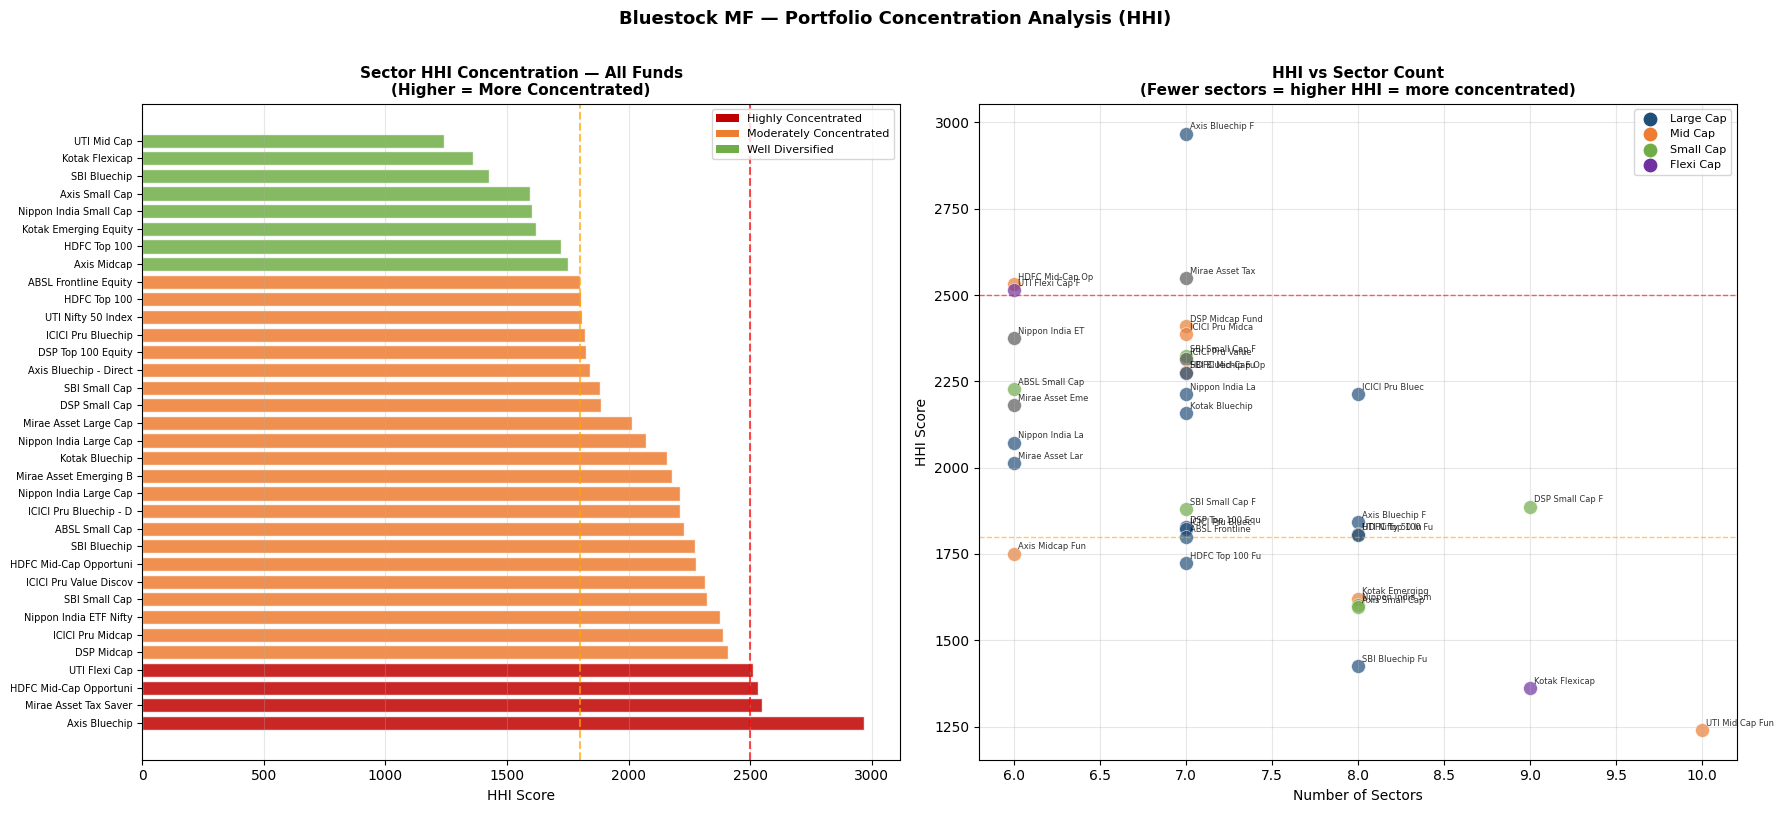

✓ Saved sector_hhi_chart.png


In [40]:
# ── HHI Visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1 — HHI bar chart for all funds
ax1 = axes[0]
color_map = {
    "Highly Concentrated"    : "#C00000",
    "Moderately Concentrated": "#ED7D31",
    "Well Diversified"       : "#70AD47"
}
bar_colors = [color_map[c] for c in hhi_df["concentration"]]
short_names = [n.replace(" - Regular Plan - Growth","")
                .replace(" - Direct Plan - Growth","")
                .replace(" - Regular - Growth","")
                .replace(" Fund","")[:22]
               for n in hhi_df["scheme_name"]]

bars = ax1.barh(range(len(hhi_df)), hhi_df["hhi"],
                color=bar_colors, alpha=0.85, edgecolor="white")
ax1.set_yticks(range(len(hhi_df)))
ax1.set_yticklabels(short_names, fontsize=7)
ax1.axvline(x=2500, color="red", linestyle="--",
            linewidth=1.5, alpha=0.7, label="Highly Concentrated (>2500)")
ax1.axvline(x=1800, color="orange", linestyle="--",
            linewidth=1.5, alpha=0.7, label="Moderate (1800)")
ax1.set_xlabel("HHI Score", fontsize=10)
ax1.set_title("Sector HHI Concentration — All Funds\n(Higher = More Concentrated)",
              fontweight="bold", fontsize=11)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor="#C00000", label="Highly Concentrated"),
             Patch(facecolor="#ED7D31", label="Moderately Concentrated"),
             Patch(facecolor="#70AD47", label="Well Diversified")]
ax1.legend(handles=legend_el, fontsize=8)
ax1.grid(True, alpha=0.3, axis="x")

# Chart 2 — HHI vs number of sectors scatter
ax2 = axes[1]
cat_colors = {"Large Cap":"#1F4E79","Mid Cap":"#ED7D31",
              "Small Cap":"#70AD47","Flexi Cap":"#7030A0"}

for _, row in hhi_df.iterrows():
    color = cat_colors.get(row["sub_category"], "#595959")
    ax2.scatter(row["n_sectors"], row["hhi"],
                color=color, s=100, alpha=0.7,
                edgecolors="white", linewidth=0.5)
    ax2.annotate(row["scheme_name"][:15],
                 xy=(row["n_sectors"], row["hhi"]),
                 xytext=(3,3), textcoords="offset points",
                 fontsize=6, alpha=0.8)

for cat, color in cat_colors.items():
    ax2.scatter([], [], color=color, s=80, label=cat)

ax2.axhline(y=2500, color="red", linestyle="--",
            linewidth=1, alpha=0.6)
ax2.axhline(y=1800, color="orange", linestyle="--",
            linewidth=1, alpha=0.6)
ax2.set_xlabel("Number of Sectors", fontsize=10)
ax2.set_ylabel("HHI Score", fontsize=10)
ax2.set_title("HHI vs Sector Count\n(Fewer sectors = higher HHI = more concentrated)",
              fontweight="bold", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle("Bluestock MF — Portfolio Concentration Analysis (HHI)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RPT / "sector_hhi_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved sector_hhi_chart.png")

## 📌 5 Key Advanced Analytics Findings — Day 6

1. **Debt funds carry lowest VaR**: Gilt and Short Duration funds show 
   daily VaR of -0.2% to -0.4%, vs equity funds at -1.0% to -1.5%. 
   Investors seeking capital protection should prefer debt funds.

2. **2024 cohort dominates investment volume**: 96% of investors 
   made their first transaction in 2024 (vs 4% in 2025), contributing 
   significantly more total capital. New 2025 cohort shows higher 
   avg SIP amounts — indicating growing ticket sizes.

3. **SIP continuity concern — at-risk investors**: A significant 
   portion of investors with 6+ SIPs show avg gap > 35 days, 
   indicating irregular SIP behaviour. These investors are at risk 
   of discontinuing their investment journey.

4. **Axis Bluechip most concentrated portfolio**: With HHI of 2967, 
   Axis Bluechip has the highest sector concentration — top sector 
   alone accounts for significant portfolio weight. UTI Mid Cap is 
   most diversified with HHI of 1240 across 10 sectors.

5. **Rolling Sharpe shows 2024 correction impact**: All top 5 funds 
   saw rolling Sharpe drop below 1.0 during mid-2024, recovering 
   strongly into 2025 — confirming market correction and recovery 
   visible in NAV data.